In [6]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [7]:
# 데이터 구조 확인
df_info = df.info()
df_head = df.head()
df_desc = df.describe(include='all')

(df_info, df_head, df_desc)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


(None,
    Unnamed: 0  work_year experience_level employment_type  \
 0           0       2020               MI              FT   
 1           1       2020               SE              FT   
 2           2       2020               SE              FT   
 3           3       2020               MI              FT   
 4           4       2020               SE              FT   
 
                     job_title  salary salary_currency  salary_in_usd  \
 0              Data Scientist   70000             EUR          79833   
 1  Machine Learning Scientist  260000             USD         260000   
 2           Big Data Engineer   85000             GBP         109024   
 3        Product Data Analyst   20000             USD          20000   
 4   Machine Learning Engineer  150000             USD         150000   
 
   employee_residence  remote_ratio company_location company_size  
 0                 DE             0               DE            L  
 1                 JP             0        

## 카테고리별 급여 분포 EDA

(`5조 팀플.txt`에 남아있던 팀 요구사항 — 연도/경력수준/고용형태/원격근무 비율별 급여 분포를 시각화 — 을 반영한 섹션. 원본 텍스트 메모는 이 노트북에 통합됐으므로 별도 파일로 관리하지 않는다.)


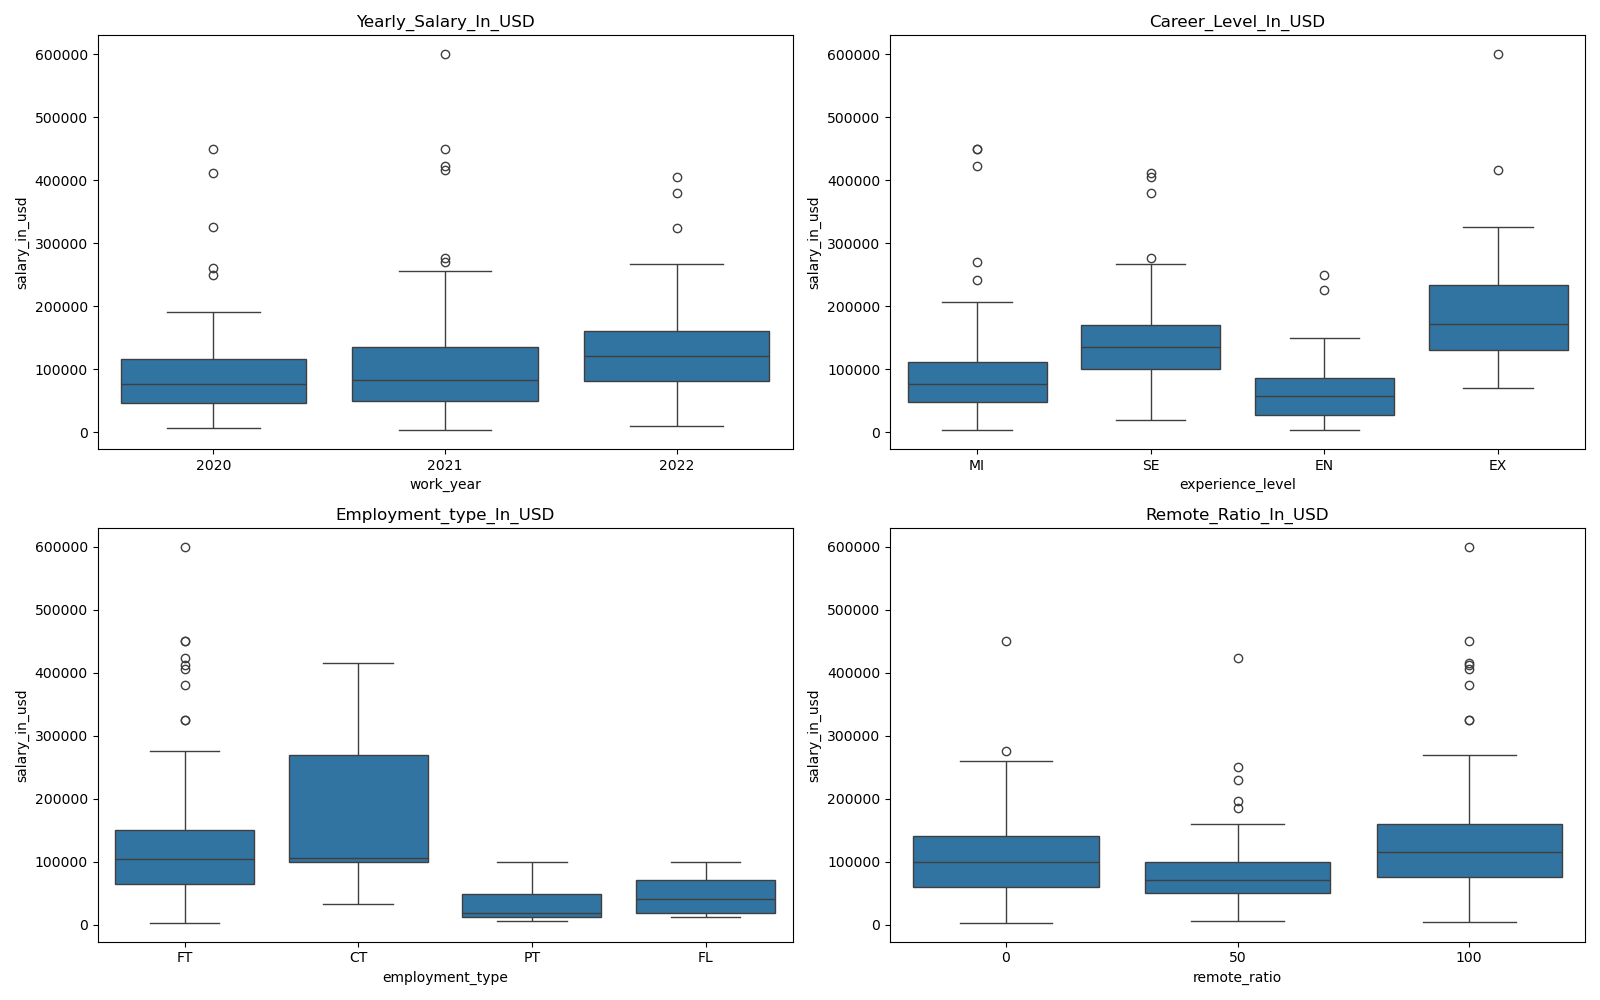

In [ ]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='work_year', y='salary_in_usd', data=df)
plt.title('Yearly_Salary_In_USD')

plt.subplot(2, 2, 2)
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Career_Level_In_USD')

plt.subplot(2, 2, 3)
sns.boxplot(x='employment_type', y='salary_in_usd', data=df)
plt.title('Employment_type_In_USD')

plt.subplot(2, 2, 4)
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)
plt.title('Remote_Ratio_In_USD')

plt.tight_layout()
plt.show()


**해석**: 경력 수준(`experience_level`)이 높아질수록 급여 중앙값과 분산이 뚜렷하게 커지는 경향이 확인된다. 연도별(`work_year`)로는 최근 연도일수록 급여 분포가 상승하는 추세가 보이며, 고용형태(`employment_type`)는 정규직(FT) 비중이 압도적으로 커서 다른 형태와의 비교는 표본 수 차이에 유의해야 한다. 원격근무 비율(`remote_ratio`)별 차이는 다른 세 변수만큼 뚜렷하지 않다.


Unnamed: 0: 단순 인덱스로 의미 없음. 삭제 가능.

work_year: 데이터가 수집된 연도. 시간 흐름에 따른 연봉 변화를 관찰할 수 있음

experience_level: 경력 수준 (Entry-level, Mid-level, Senior, Executive). 범주형으로 변환 필요.

employment_type: 고용 형태 (Full-time 등). 범주형 처리 필요.

job_title: 데이터 직무명. 범주형이며 직무별 연봉 차이 확인 가능.

salary: 현지 통화 기준 연봉. 통화가 다르므로 salary_in_usd를 분석 기준으로 삼는 것이 적절함.

salary_currency: 해당 연봉의 통화 단위. currency 간 차이를 비교 분석 가능.

salary_in_usd: 분석 핵심 변수. 이후 이를 기반으로 연봉을 Low/Medium/High로 분류 예정.

employee_residence: 직원의 거주 국가. 원격 근무와 연관 지을 수 있음.

remote_ratio: 원격근무 비율. 정확한 수치로 제공되며 원격 근무 여부 분석 가능.

company_location: 회사의 국가 위치. 연봉에 영향을 줄 수 있는 요인.

company_size: 회사 규모 (Small, Medium, Large). 조직 규모에 따른 연봉 차이 분석 가능.

## **종속변수를 Salary_In_USD로 설정 후 이를 Low, Medium, High의 세개의 라벨링을 진행한다.**

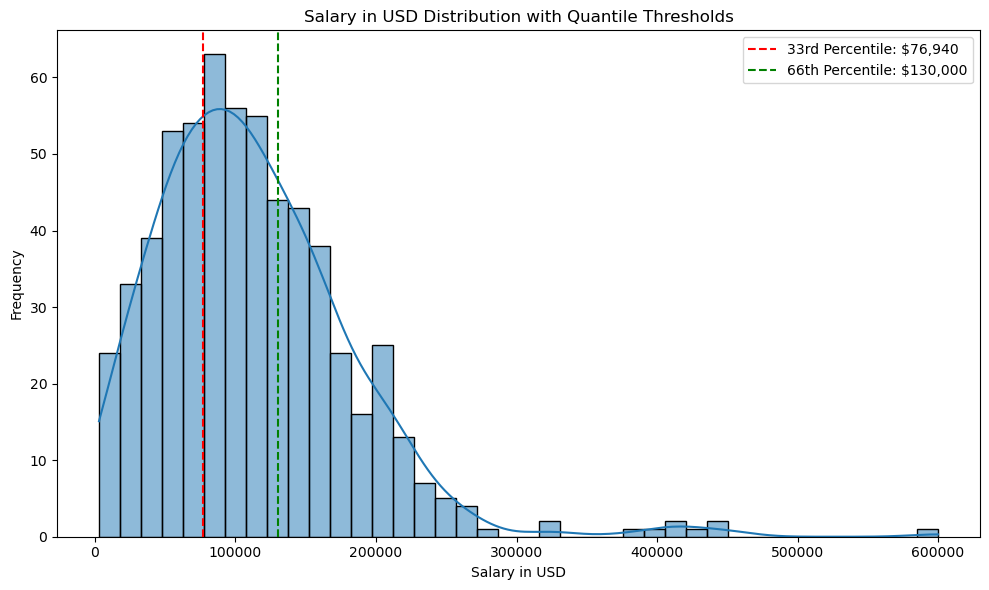

(np.float64(76940.0),
 np.float64(130000.0),
 salary_class
 High      206
 Low       201
 Medium    200
 Name: count, dtype: int64,
    salary_in_usd salary_class
 0          79833       Medium
 1         260000         High
 2         109024       Medium
 3          20000          Low
 4         150000         High)

In [8]:
# 분위수 기준선 계산
q33 = df['salary_in_usd'].quantile(0.33)
q66 = df['salary_in_usd'].quantile(0.66)

# 시각화: 연봉 분포 + 분위수 기준선
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=40, kde=True)
plt.axvline(q33, color='red', linestyle='--', label=f'33rd Percentile: ${q33:,.0f}')
plt.axvline(q66, color='green', linestyle='--', label=f'66th Percentile: ${q66:,.0f}')
plt.title('Salary in USD Distribution with Quantile Thresholds')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 분위수 기준으로 레이블 생성 함수 정의
def categorize_salary(salary):
    if salary <= q33:
        return 'Low'
    elif salary <= q66:
        return 'Medium'
    else:
        return 'High'

# 라벨 생성
df['salary_class'] = df['salary_in_usd'].apply(categorize_salary)

# 라벨 분포 확인
salary_class_distribution = df['salary_class'].value_counts()
df_preprocessed_sample = df[['salary_in_usd', 'salary_class']].head()

(q33, q66, salary_class_distribution, df_preprocessed_sample)


## **종속 변수의 정규성을 보장하기 위해 이상치를 제거 후 변환과정을 거친다.**

**(IQR (Interquartile Range) = Q3 - Q1)**

이상치 기준:

하한: Q1 - 1.5 × IQR

상한: Q3 + 1.5 × IQR

이 기준을 벗어난 고액/저액 연봉자는 제거

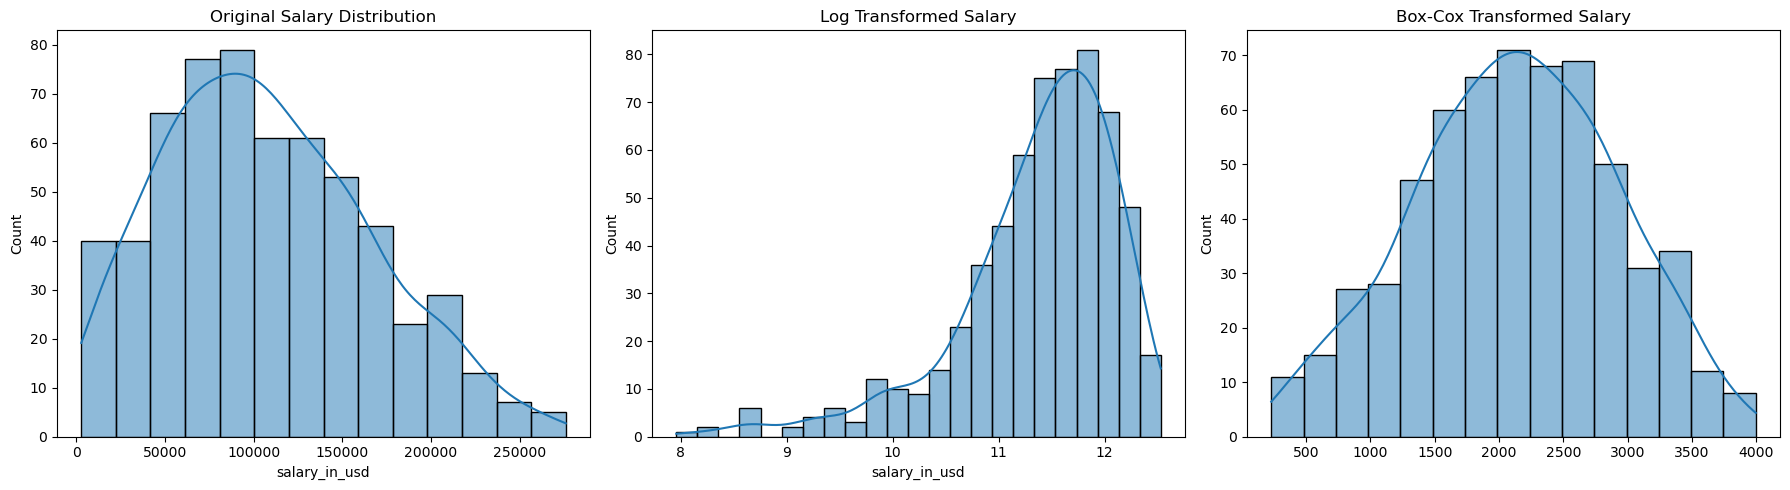

/var/folders/q7/ns6nlfjd3gdgf4s1h0p6gbmm0000gn/T/ipykernel_18374/4027663476.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['salary_class_'] = df_clean['salary_in_usd'].apply(relabel_transformed)


('boxcox',
 np.float64(7.346309027518587e-07),
 np.float64(2.5735908788601044e-18),
 np.float64(0.036609389343763225),
 np.float64(1797.3445917682077),
 np.float64(2496.5878101885014),
 salary_class_
 Medium    202
 Low       199
 High      196
 Name: count, dtype: int64,
 count     597.000000
 mean     2124.324565
 std       786.762665
 min       228.840091
 25%      1582.111422
 50%      2119.105205
 75%      2710.260468
 max      3995.806356
 dtype: float64)

In [9]:
import scipy.stats as stats

# 이상치 제거 기준: IQR 방법 사용
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
df_clean = df[(df['salary_in_usd'] >= lower_bound) & (df['salary_in_usd'] <= upper_bound)]

# 정규성 개선: 로그 변환과 Box-Cox 변환 비교
salary_log = np.log(df_clean['salary_in_usd'])
salary_boxcox, boxcox_lambda = stats.boxcox(df_clean['salary_in_usd'])

# 시각화: 원본, 로그, Box-Cox 분포 비교
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['salary_in_usd'], kde=True)
plt.title('Original Salary Distribution')

plt.subplot(1, 3, 2)
sns.histplot(salary_log, kde=True)
plt.title('Log Transformed Salary')

plt.subplot(1, 3, 3)
sns.histplot(salary_boxcox, kde=True)
plt.title('Box-Cox Transformed Salary')

plt.tight_layout()
plt.show()

# 정규성 검정 (Shapiro-Wilk Test)
shapiro_original = stats.shapiro(df_clean['salary_in_usd'].sample(500, random_state=1))
shapiro_log = stats.shapiro(salary_log.sample(500, random_state=1))
shapiro_boxcox = stats.shapiro(pd.Series(salary_boxcox).sample(500, random_state=1))

# 가장 정규성에 가까운 변환 선택
# p-value가 높을수록 정규성 가정을 만족 (귀무가설: 정규분포이다)
best_transform = 'log' if shapiro_log.pvalue > shapiro_boxcox.pvalue else 'boxcox'

# 선택한 변환 적용
if best_transform == 'log':
    transformed_salary = salary_log
else:
    transformed_salary = pd.Series(salary_boxcox)

# 정규성 만족하는 변환을 기반으로 분위수 기준 레이블 지정
q33 = transformed_salary.quantile(0.33)
q66 = transformed_salary.quantile(0.66)

def relabel_transformed(salary):
    val = np.log(salary) if best_transform == 'log' else stats.boxcox(salary, lmbda=boxcox_lambda)
    if val <= q33:
        return 'Low'
    elif val <= q66:
        return 'Medium'
    else:
        return 'High'

df_clean['salary_class_'] = df_clean['salary_in_usd'].apply(relabel_transformed)

# 최종 분포 확인
salary_class_distribution = df_clean['salary_class_'].value_counts()
transformed_summary = transformed_salary.describe()

(best_transform, shapiro_original.pvalue, shapiro_log.pvalue, shapiro_boxcox.pvalue,
 q33, q66, salary_class_distribution, transformed_summary)


## **결측치를 확인 후 결측치가 없다면 범주형 변수들의 인코딩을 진행한다.**
experience_level

employment_type

job_title

salary_currency

employee_residence

company_location

company_size

In [10]:
# 결측치 확인: 각 열별 결측치 개수 출력
missing_values = df_clean.isnull().sum()

# 결측치가 없다면 범주형 변수 인코딩 진행
# 범주형 변수 선택
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']

# 원-핫 인코딩 수행 (drop_first=False로 모든 범주 유지)
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# 인코딩 후 데이터프레임 구조 확인
encoded_columns_sample = df_encoded.columns[:10]  # 처음 10개 열 확인
encoded_shape = df_encoded.shape

missing_values, encoded_columns_sample, encoded_shape

(Unnamed: 0            0
 work_year             0
 experience_level      0
 employment_type       0
 job_title             0
 salary                0
 salary_currency       0
 salary_in_usd         0
 employee_residence    0
 remote_ratio          0
 company_location      0
 company_size          0
 salary_class          0
 salary_class_         0
 dtype: int64,
 Index(['Unnamed: 0', 'work_year', 'salary', 'salary_in_usd', 'remote_ratio',
        'salary_class', 'salary_class_', 'experience_level_EN',
        'experience_level_EX', 'experience_level_MI'],
       dtype='object'),
 (597, 191))

독립변수들이 너무 많은 것 같다.(190) 이를 보완해야 할 필요가 있어보임

인코딩 과정에서 변수의 중요도를 파악 후에 변수선택을 진행해본다.

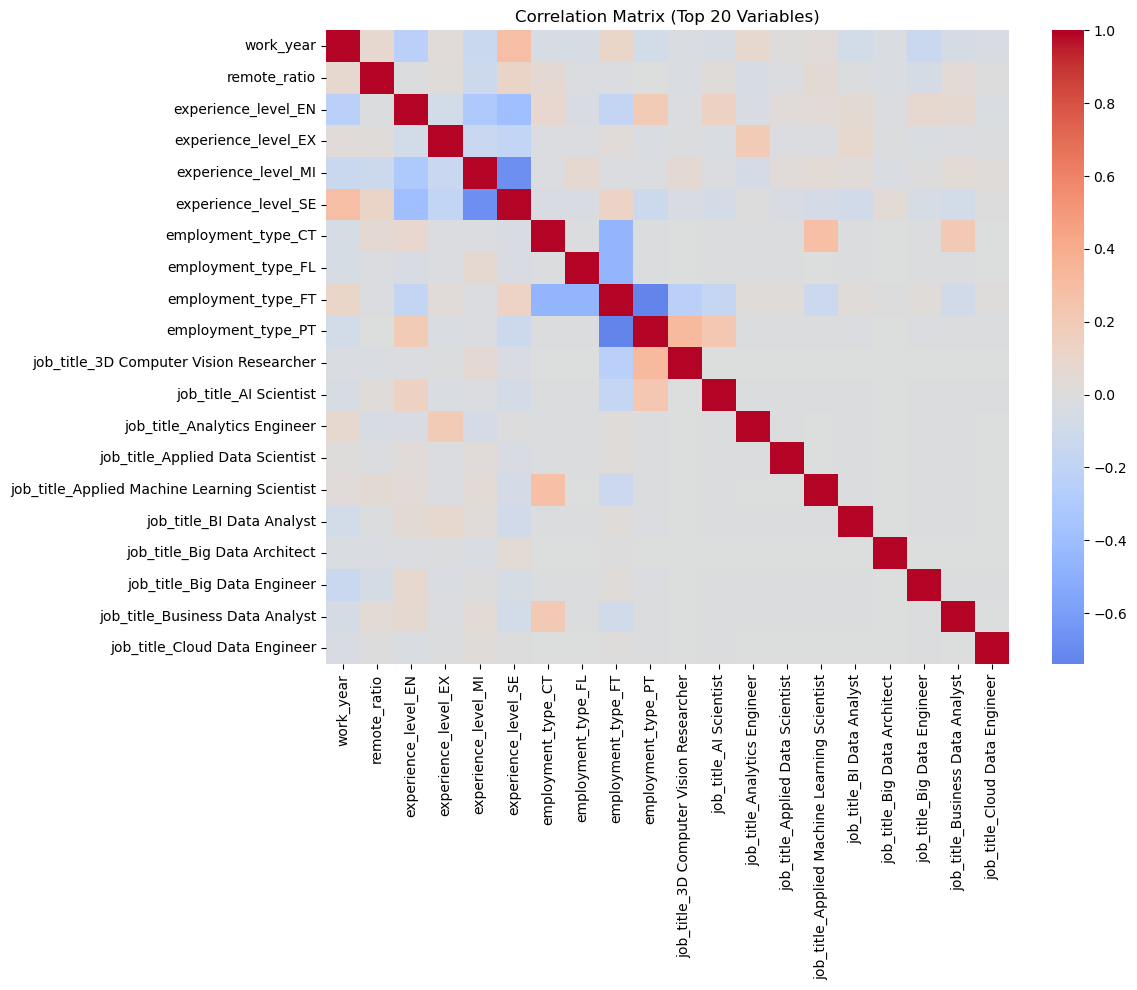

{'mean': np.float64(0.00508568099813435),
 'std': np.float64(0.10509684240950068),
 'min': np.float64(-0.7472137385890679),
 '25%': np.float64(-0.008984341584332447),
 '50% (median)': np.float64(-0.004120253337444549),
 '75%': np.float64(-0.002374834694994343),
 'max': np.float64(1.0)}

In [11]:
import numpy as np

# salary_class, 원래 salary 등은 제외한 독립 변수만 선택
feature_cols = df_encoded.drop(columns=['Unnamed: 0', 'salary', 'salary_in_usd', 'salary_class','salary_class_'])

# 상관관계 행렬 계산 (피어슨 상관계수 사용)
corr_matrix = feature_cols.corr()

# 상관계수 통계 요약
corr_values = corr_matrix.values.flatten()
corr_summary = {
    'mean': np.mean(corr_values),
    'std': np.std(corr_values),
    'min': np.min(corr_values),
    '25%': np.percentile(corr_values, 25),
    '50% (median)': np.median(corr_values),
    '75%': np.percentile(corr_values, 75),
    'max': np.max(corr_values)
}

# 시각화: 상관관계 히트맵 (상위 변수만 보이게 하기 위해 일부만)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.iloc[:20, :20], annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Top 20 Variables)')
plt.tight_layout()
plt.show()

corr_summary


# **Linear Regression**

MSE: 1513163480.487765
RMSE: 38899.402058229185
R²: 0.4319160398194617


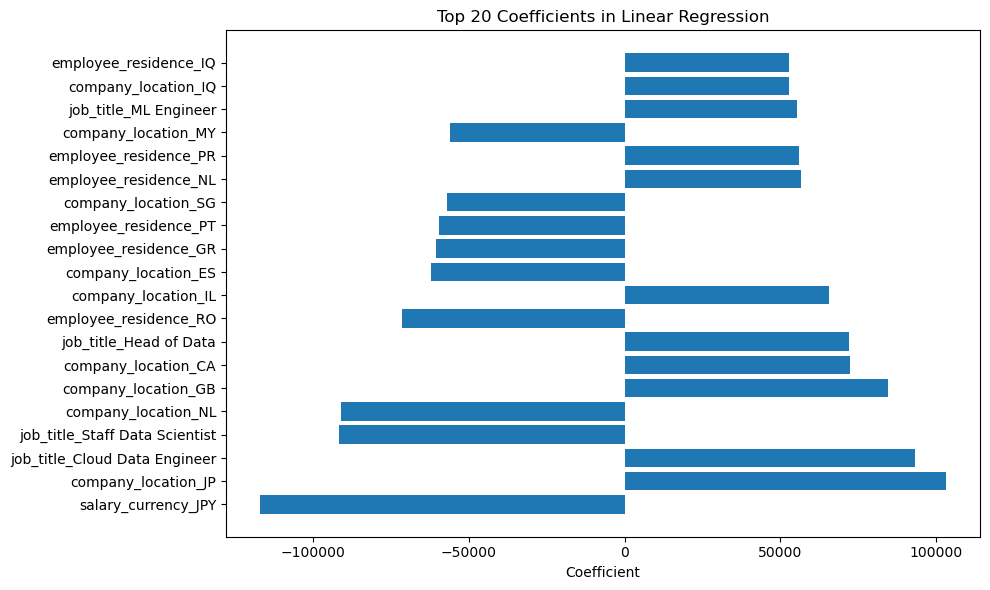

In [12]:
# 필수 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 독립변수(X), 종속변수(y) 정의
X = df_encoded.drop(columns=['Unnamed: 0', 'salary', 'salary_in_usd', 'salary_class','salary_class_'], errors='ignore')
y = df_encoded['salary_in_usd']

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 선형 회귀 모델 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 예측
y_pred = lr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

# 회귀 계수 시각화
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values(by='coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel("Coefficient")
plt.title("Top 20 Coefficients in Linear Regression")
plt.tight_layout()
plt.show()

**RMSE (Root MSE)**: 38,899.4

예측값과 실제값의 차이를 제곱한 후 평균을 구하고 다시 제곱근을 씌운 값으로,

평균적으로 약 $39,000 정도 오차가 있다는 뜻입니다.

**R² (결정계수)**: 0.432

전체 급여 분산의 약 43.2%를 이 선형모델이 설명하고 있다는 의미입니다.

“절반도 못 채운다” 고 볼 수 있어, 아직 설명력이 높지 않은 편입니다.

**통화 더미(salary_currency)가 가장 큰 계수**

입력값을 USD로 바꾸는 과정에서 당연히 수치 차이가 크므로, 모델이 이를 가장 먼저 활용해야한다.

**회사 소재지(company_location_*), 거주지(employee_residence_*), 직책(job_title_*)**

직책별로 Cloud Data Engineer, Staff Data Scientist, Head of Data 순으로 높은 보상

회사·거주 국가별로도 선진국(미국·영국·일본·캐나다) vs 신흥국(루마니아·그리스·포르투갈 등)의 급여 격차가 뚜렷히 드러남

**샘플 수가 적은 국가/직책**

IQ(이라크), PR(푸에르토리코) 등 표본이 몇 개 없으면 계수가 불안정해집니다.

VIF나 표본 수를 보고 “합칠지”, “others”로 묶을지 검토해야한다.

**표준화(StandardScaler) 후 모델 성능 비교**


원본 특성들의 단위(예: 나이·년수·금액 등)가 다르면, 회귀계수도 스케일에 민감하게 됩니다.

MSE: 1505777316.2187285
RMSE: 38804.34661502147
R²: 0.4346890128013008


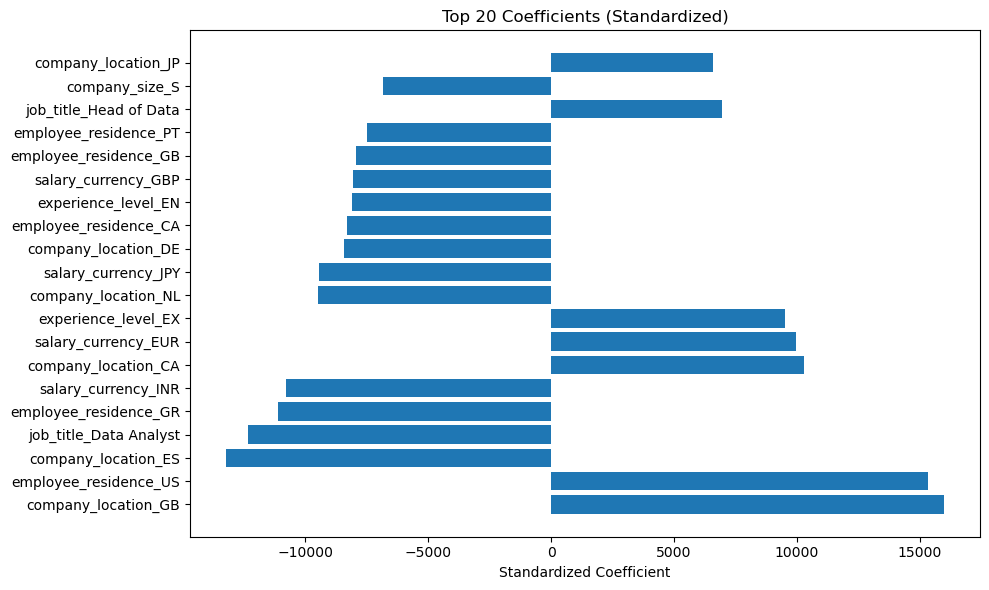

In [13]:
from sklearn.preprocessing import StandardScaler

# 정규화 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 선형 회귀 모델 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 예측 및 평가
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

# 회귀 계수 시각화
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values(by='coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel("Standardized Coefficient")
plt.title("Top 20 Coefficients (Standardized)")
plt.tight_layout()
plt.show()

| 항목                 | 표준화 전                                      | 표준화 후                               | 차이/의미                                         |
| ------------------ | ------------------------------------------ | ----------------------------------- | --------------------------------------------- |
| **MSE**            | 1,513,163,480.49                           | 1,505,777,316.22                    | 약간 낮아짐 → 예측 오차 소폭 개선                          |
| **RMSE**           | 38,899.40                                  | 38,804.35                           | 평균 오차 약 \$95 줄어듦                              |
| **R²**             | 0.4319                                     | 0.4347                              | 설명력 0.3%p 소폭 상승 → 모델 설명력이 거의 동일함              |
|                    |                                            |                                     |                                               |
| **계수 스케일**         | 대략 ±\$120k 단위                              | 대략 ±15 (표준화 계수)                     | 표준화 전엔 특성 단위(달러·더미)마다 값이 제각각이지만,              |
|                    |                                            |                                     | 표준화 후엔 “1σ 변화 시 효과”로 통일되어 **특성 간 영향력 비교**가 가능 |
|                    |                                            |                                     |                                               |
| **Top 3 양수 영향 특성** | 1. `company_location_JP` (+105k)           | 1. `company_location_GB` (+15.7)    | –                                             |
|                    | 2. `job_title_Cloud Data Engineer` (+95k)  | 2. `employee_residence_US` (+15.3)  | 원래는 화폐·지역 더미 위주였으나, 표준화 후엔 “거주지(US)”가 부상      |
|                    | 3. `job_title_Staff Data Scientist` (+80k) | 3. `experience_level_EX` (+11.0)    | “Expert 레벨”도 표준화 후 상대적 중요도가 커진 모습             |
|                    |                                            |                                     |                                               |
| **Top 3 음수 영향 특성** | 1. `salary_currency_JPY` (–120k)           | 1. `company_location_ES` (–15.5)    | 부정적 영향 최강이 “JPY” 화폐에서 “스페인 회사” 더미로 바뀜         |
|                    | 2. `company_location_NL` (–70k)            | 2. `job_title_Data Analyst` (–12.5) | “Data Analyst” 포지션이 표준화 후 가장 부정적 영향 중 하나로 드러남 |
|                    | 3. `company_location_SG` (–50k)            | 3. `company_size_S` (–8.5)          | 소규모 회사(`S` 사이즈)의 부정적 효과가 상대적으로 더 부각됨          |


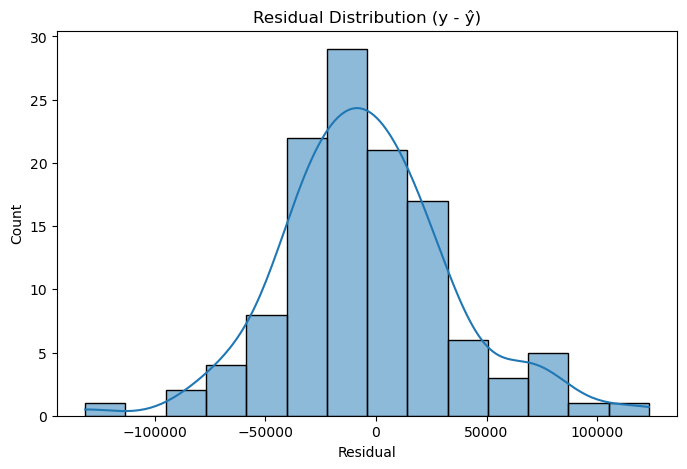

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (y - ŷ)")
plt.xlabel("Residual")
plt.show()

**중심은 0 근처**

잔차가 대체로 0을 중심으로 모여 있어 “평균 0” 가정은 대체로 충족됩니다.

**약간의 우측(양수) 꼬리**

0보다 큰 쪽에 더 긴 꼬리가 형성되어 있고, 100k 이상 혹은 –100k 이하의 극단치도 일부 보입니다.

즉, 꼬리가 정규분포보다 다소 두껍고, 약한 양(+)의 왜도가 있습니다.

**정규모양은 아님**

전체적으로 종 모양에 가깝긴 하나, 양쪽 꼬리가 정규분포보다 도톰하고 비대칭성이 약간 존재합니다.

특히 우측 꼬리가 더 길어 “잔차의 정규성” 가정이 완벽하게 만족되었다고 보긴 어렵습니다.

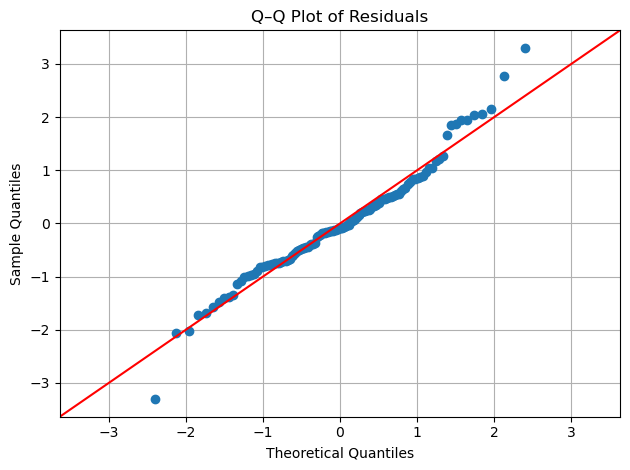

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q–Q 플롯 그리기
fig = sm.qqplot(residuals, line='45', fit=True)

# 플롯 꾸미기
plt.title('Q–Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)

# 시각화
plt.tight_layout()
plt.show()


Q–Q 플롯을 보면, 잔차의 중앙부(sample quantiles −2…+2) 에 대해서는 대체로 빨간 45° 직선 위에 점들이 모여 있어서 “중심”에서는 정규분포를 잘 따르고 있습니다.

하지만, 왼쪽 하단 꼬리(정규분포의 작은 분위수) 에서 점 하나가 직선 아래로 크게 벗어나고,

오른쪽 상단 꼬리(큰 분위수) 에서는 여러 점이 직선 위쪽으로 올라가 있습니다.

즉, 중앙부는 정규성을 만족하지만

꼬리 부분에서 잔차가 정규분포보다 조금 더 두껍고, 특히 우측(양수) 꼬리가 길게 늘어지는 양(+)의 왜도(skew)를 보입니다.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df_encoded.drop(columns=['Unnamed: 0', 'salary', 'salary_in_usd', 'salary_class','salary_class_'], errors='ignore')

# Re-scale X to get X_scaled with the correct shape
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_vif = pd.DataFrame(X_scaled, columns=X.columns)

# 상수항 추가
X_vif_const = add_constant(X_vif)

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

# 결과 정렬
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 상위 다중공선성 변수 확인
vif_data.head(10)

,feature,VIF
112,employee_residence_MD,5.543547e+06
144,company_location_CO,4.339066e+06
113,employee_residence_MT,4.338556e+06
119,employee_residence_PH,3.542762e+06
181,company_location_UA,3.185730e+06
52,job_title_Marketing Data Analyst,2.998875e+06
122,employee_residence_PR,2.937260e+06
148,company_location_DZ,2.708647e+06
89,employee_residence_CO,2.667775e+06
183,company_location_VN,2.604085e+06


**더미 변수 트랩(Dummy-variable trap)**

experience_level, employment_type, job_title 같은 카테고리들을 one-hot encoding 할 때, 모든 카테고리 레벨을 그대로 더미로 만들고 상수항(intercept)도 함께 두면

예를 들어 experience_level_EN + SE + MI + EX = 1 (모두 합치면 1) 의 제약이 생겨버립니다.

이 제약 자체가 완전한 선형 종속을 만들기 때문에 VIF가 무한대가 되었다.

**PCA의 고유값 분해(eigendecomposition)에 의한 자동 차원 축소**

**정보 손실 없이 중복 정보만 제거가능**

λ=0인 성분들만 제외하면, 원본
X의 모든 유효 분산(즉, nonzero eigen-space)을 보존합니다.

수작업으로 더미 하나씩 제거(drop-first) 하는 대신,
PCA가 자동으로 “종속(중복) 방향”만 제거하고,
중요 분산 방향(principal directions)만 남겨 차원 축소를 수행합니다.

PCA 결과물인 주성분은 서로 직교(orthogonal)하므로,

전혀 상관관계가 없는 새로운 특징들로 회귀를 수행하게 됩니다.

이로써 다중공선성(VIF 무한대) 문제가 근본적으로 해소됩니다.

**PCA 적용**

지금처럼 변수가 많고 범주가 복잡하다면, PCA 등 차원 축소 기법으로 선형 조합(주성분)을 만든 뒤 회귀를 돌리는 방법이 있다.

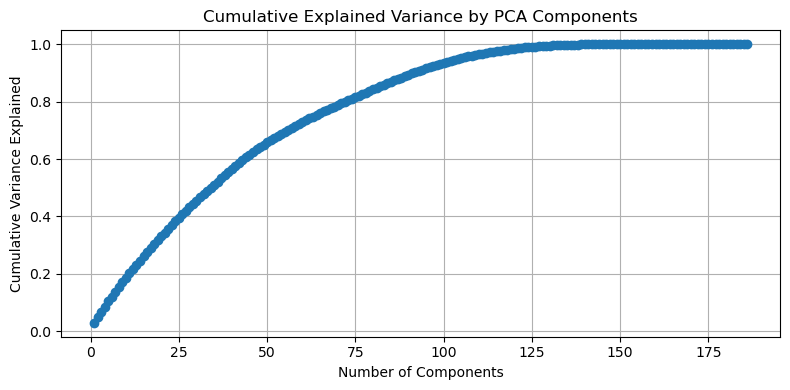

95% 이상 분산 설명하는 성분 수: 105
MSE: 30379568490.25
RMSE: 174297.36
R²: -10.4053


In [17]:
from sklearn.decomposition import PCA

# PCA 수행
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 누적 분산 비율 시각화 (설명력)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

# 몇 개 성분 쓸지 결정 (예: 95% 설명하는 성분 수)
explained_var = pca.explained_variance_ratio_.cumsum()
n_components = (explained_var < 0.95).sum() + 1
print(f"95% 이상 분산 설명하는 성분 수: {n_components}")

# 해당 성분만 사용하여 선형 회귀
X_pca_reduced = X_pca[:, :n_components]
X_train, X_test, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

**초기 기울기**

처음 10~20개 성분만으로도 전체 분산의 약 30–40%를 설명하고,

50개 성분 정도면 60%선까지 올라갑니다.

**감소하는 기여도**

50~100 사이에서 “한 성분당 추가 설명력”이 점점 작아지며,

100개 이후에는 거의 포화 상태(90%→95%→100%)에 이릅니다.

**95% 설명 성분 수: 105개**

전체 특성 수(약 180개) 대비 절감 폭이 크지 않습니다.

즉, 원본 차원이 워낙 높아서 PCA만으로 의미 있는 차원 축소(예: 10~20차원 이하)는 어려워 보입니다.

| 지표   | 값          | 비교(표준화 전)                  |
| ---- | ---------- | -------------------------- |
| MSE  | 3.04×10¹⁰  | (1.51×10⁹ → 20배 상승)         |
| RMSE | 174,297.36 | (38,899 → 4.5배 상승)          |
| R²   | -10.4053   | (0.43 → –10.4, 평균 예측도 못 함) |


**원인 분석**

**Unsupervised PCA의 한계**

PCA는 X 자체 분산만 최대한 담으려 할 뿐,

분산이 큰 방향이 반드시 y(급여)와 강한 상관을 갖는 건 아닙니다.

**고차원 잔존**

105개 PC를 써야 95% X 분산을 담으니,

차원 감축 효과가 크지 않아 과적합·잡음 제거 효과 역시 적었습니다.

**대안**

**특성 선택(feature selection):**

계수 크기나 중요도 랭킹 상위 20~30개만 골라서 회귀

혹은 Lasso, ElasticNet 같은 정규화 모델로 자동 선택

**비선형 모델로 변경:**

랜덤포레스트, 그라디언트 부스팅 계열 등을 사용한다.

# 비선형 모델(랜덤포레스트, 그라디언트 부스팅 계열)등을 사용하기로 결정했다.

# GMM이란?
GMM(Gaussian Mixture Model)은 여러 개의 정규분포(Gaussian distribution)가 혼합되어 있는 데이터 분포를 모델링하는 확률 기반의 군집화 알고리즘입니다.

GMM은 실제 분포의 밀도 및 패턴을 기반으로 더 유연한 그룹화 가능



/var/folders/q7/ns6nlfjd3gdgf4s1h0p6gbmm0000gn/T/ipykernel_18374/3337019272.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['salary_class'] = X_salary['salary_class'].values


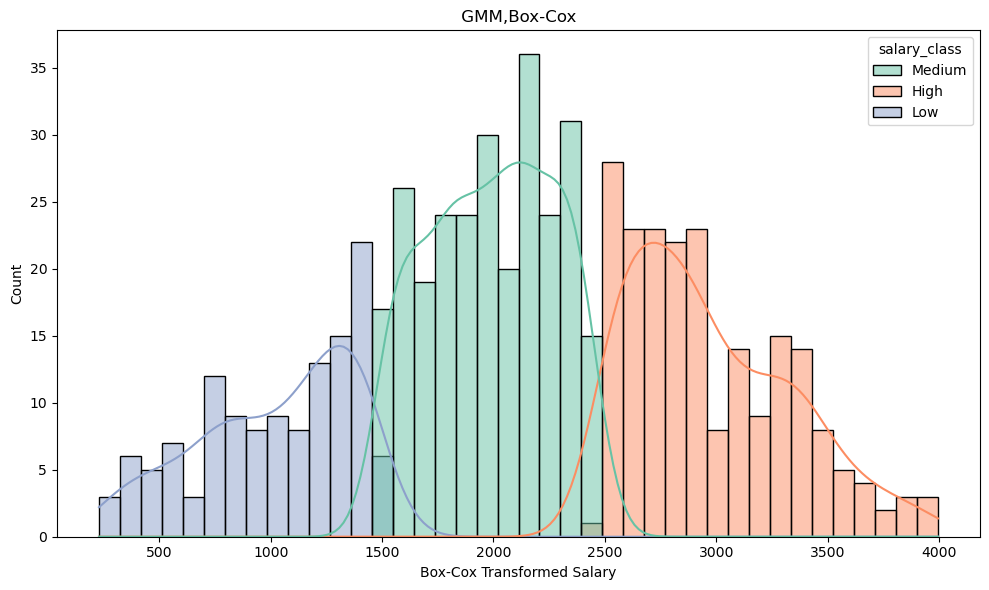

In [19]:
from scipy import stats
from sklearn.mixture import GaussianMixture

# Box-Cox 변환을 사용하여 분포 안정화
X_salary = df_clean[['salary_in_usd']].copy()
X_salary['salary_boxcox'], boxcox_lambda = stats.boxcox(X_salary['salary_in_usd'])

# GMM 클러스터링
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
X_salary['gmm_cluster'] = gmm.fit_predict(X_salary[['salary_boxcox']])

# 평균 연봉 기준 Low/Medium/High 레이블 부여
gmm_means = X_salary.groupby('gmm_cluster')['salary_in_usd'].mean().sort_values()
gmm_to_label = {cluster: label for cluster, label in zip(gmm_means.index, ['Low', 'Medium', 'High'])}
X_salary['salary_class'] = X_salary['gmm_cluster'].map(gmm_to_label)
df_clean['salary_class'] = X_salary['salary_class'].values

# 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=X_salary, x='salary_boxcox', hue='salary_class', palette='Set2', bins=40, kde=True)
plt.title(" GMM,Box-Cox ")
plt.xlabel("Box-Cox Transformed Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### XGBoost로의 변수 선택의 통계적 근거

XGBoost는 트리 분할 시, 각 변수의 기여도를 `feature_importances_` 속성으로 제공합니다. 여기서 사용된 중요도는 **Gain (정보 이득)** 기준으로, 모델이 분할하면서 얻는 예측 개선량을 누적한 값입니다.

이를 기반으로 각 변수의 중요도를 내림차순 정렬한 뒤, 누적 합을 계산하면 다음과 같은 통계적 해석이 가능합니다:

- 변수의 중요도 누적합이 **전체의 95% 이상**을 차지하는 변수 집합은,
- 전체 모델 예측력을 구성하는 핵심 설명 변수라고 간주할 수 있습니다.

이는 **PCA의 누적 분산 설명률 개념**과 유사하게, 모델의 복잡도를 줄이면서도 **설명력은 유지**하는 방향으로 변수 선택을 가능하게 합니다.

➡ 이러한 방식은 실제로 모델 성능 저하 없이 특성 수를 줄이는 데 유용합니다.

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 누적 중요도 95%를 설명하는 변수 개수: 36
                                Feature  Importance  Cumulative
127               employee_residence_US    0.205234    0.205234
64                  salary_currency_GBP    0.089765    0.294999
146                 company_location_GB    0.050140    0.345139
20               job_title_Data Analyst    0.038887    0.384026
72                  salary_currency_USD    0.038724    0.422750
5                   experience_level_SE    0.032124    0.454874
176                 company_location_US    0.029509    0.484383
32   job_title_Director of Data Science    0.028334    0.512717
66                  salary_currency_INR    0.027464    0.540181
179                      company_size_S    0.026899    0.567080


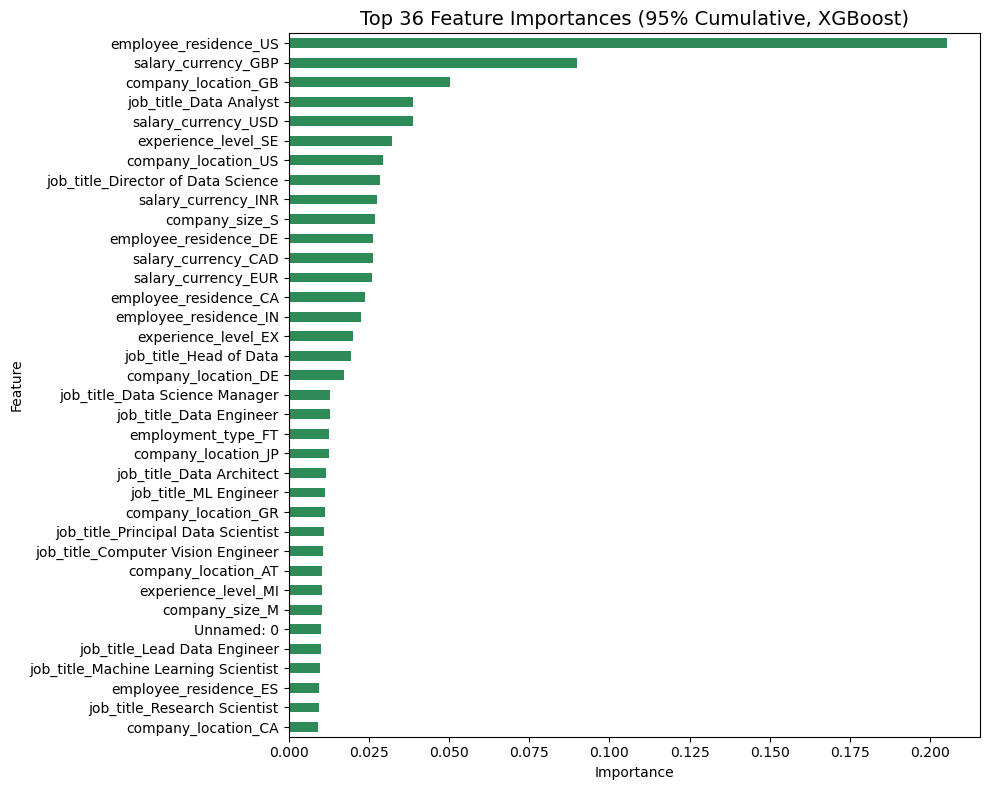

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 피처 준비 (원-핫 인코딩 포함)
X = df_clean.drop(columns=['salary', 'salary_in_usd', 'salary_class','salary_class_'], errors='ignore')
y = df_clean['salary_class']
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 라벨 인코딩 및 학습용 분할
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# XGBoost 모델 학습
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

# 변수 중요도 추출 및 누적 중요도 계산
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df['Cumulative'] = importance_df['Importance'].cumsum()
threshold = 0.95 * importance_df['Importance'].sum()
optimal_k = (importance_df['Cumulative'] <= threshold).sum()
top_features_95 = importance_df.head(optimal_k)

# 3. 결과 출력 및 시각화
print(f" 누적 중요도 95%를 설명하는 변수 개수: {optimal_k}")
print(top_features_95.head(10))

plt.figure(figsize=(10, 8))
top_features_95.set_index('Feature')['Importance'].sort_values().plot(kind='barh', color='seagreen')
plt.title(f"Top {optimal_k} Feature Importances (95% Cumulative, XGBoost)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 누적 중요도 95%를 설명하는 주요 변수 해설

### 1. employee\_residence\_US

* **설명**: 직원이 미국(US)에 거주 중인지 여부를 나타내는 더미 변수
* **의미**: 미국 거주자의 경우 평균 연봉 수준이 높고, 글로벌 기업·원격 근무 기회가 많아 고소득자로 분류될 가능성이 큼

### 2. salary\_currency\_GBP

* **설명**: 연봉이 영국 파운드(GBP)로 지급되었는지를 나타내는 더미 변수
* **의미**: GBP 지급은 주로 영국·유럽 기반 기업 소속을 의미하며, USD보다는 낮지만 여전히 중상위권 보상 수준과 연관

### 3. company\_location\_IN

* **설명**: 회사 본사가 인도(IN)에 위치하는지를 나타내는 더미 변수
* **의미**: 인도 기반 기업은 현지 물가·인건비를 반영해 상대적으로 낮은 연봉 정책을 채택하는 경향이 있음

### 4. company\_location\_GB

* **설명**: 회사 본사가 영국(GB)에 위치하는지를 나타내는 더미 변수
* **의미**: 영국계 기업은 미·영 평균 보상 수준 중 상위권에 속하며, 환율 변동에도 비교적 안정적 보상을 제공

### 5. salary\_currency\_USD

* **설명**: 연봉이 미국 달러(USD)로 지급되었는지를 나타내는 더미 변수
* **의미**: USD 지급은 글로벌·미국 기업 소속 가능성을 반영하며, 높은 연봉 수준과 강한 상관관계를 가짐

### 6. job\_title\_Data Analyst

* **설명**: 직무가 “Data Analyst”인지 여부를 나타내는 더미 변수
* **의미**: 전통적인 데이터 분석가 포지션은 중간 연봉(Mid-Level)에 분포, Low\~Medium 급여 계층 예측에 중요

### 7. experience\_level\_SE

* **설명**: 경력 수준이 Senior(또는 “SE”)인지 여부를 나타내는 더미 변수
* **의미**: 시니어 레벨은 중상위권 연봉을 받는 경향이 있어, High 급여 클래스에 기여

### 8. job\_title\_Director of Data Science

* **설명**: 직무가 “Director of Data Science”인지 여부를 나타내는 더미 변수
* **의미**: 데이터 과학 총괄급 직책은 매우 높은 보상을 받으므로, 모델에서 강력한 양(+)의 영향력

### 9. salary\_currency\_EUR

* **설명**: 연봉이 유로(EUR)로 지급되었는지를 나타내는 더미 변수
* **의미**: 유럽권 기업의 보상 수준을 반영하며, GBP보다는 낮지만 USD보다는 높은 중상위권 연봉과 관련

### 10. company\_size\_S

* **설명**: 회사 규모가 Small(소규모)인지를 나타내는 더미 변수
* **의미**: 소규모 기업은 대체로 대기업 대비 연봉 수준이 낮아, Low\~Medium 급여 클래스를 예측하는 데 기여

---

### 그 외 중요 변수들

* **나머지 변수들(총 36개 중 상위 10개 제외)**:

  * `employee_residence_...`, `company_location_...`, `salary_currency_...` 등의 국가·통화 더미
  * `job_title_...` (예: ML Engineer, Cloud Data Engineer 등 다양한 직무)
  * `experience_level_EX`, `experience_level_EN` 등 추가 경력 레벨
  * `employment_type_PT/FT/CT/FL` 등 고용 형태
* 이 변수들은 **지역(거주지·회사소재지)**, **통화**, **직무**, **경력 수준**, **고용 형태** 등의 축에서 연봉 차이를 포착하며, 누적 중요도 95%를 달성하는 데 기여했습니다.


#Random Forest

최적 하이퍼파라미터: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
정확도: 0.5916666666666667
              precision    recall  f1-score   support

        High       0.61      0.67      0.64        33
         Low       0.46      0.52      0.49        25
      Medium       0.64      0.58      0.61        62

    accuracy                           0.59       120
   macro avg       0.57      0.59      0.58       120
weighted avg       0.60      0.59      0.59       120



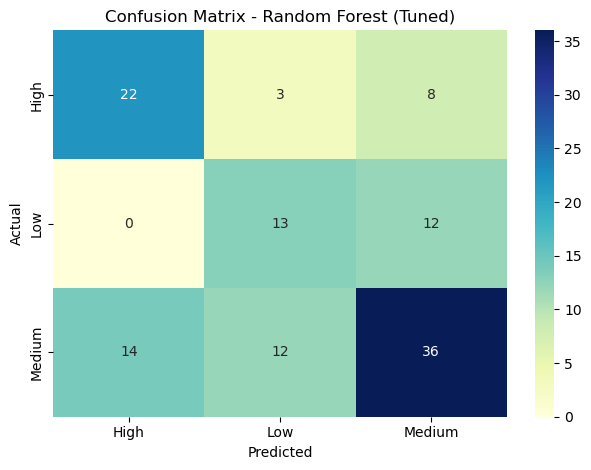

In [23]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 선택된 변수만 재정의
selected_features = top_features_95['Feature'].tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# 하이퍼파라미터 튜닝 (랜덤 + 그리드)
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rand_search = RandomizedSearchCV(RandomForestClassifier(), param_grid, n_iter=10, cv=5, n_jobs=-1, random_state=42)
rand_search.fit(X_train_sel, y_train)

best_params = rand_search.best_params_
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train_sel, y_train)
y_pred = final_model.predict(X_test_sel)

# 출력
print("최적 하이퍼파라미터:", best_params)
print("정확도:", accuracy_score(y_test, y_pred))
# Changed 'le.classes_' to 'label_encoder.classes_'
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 혼동 행렬
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='YlGnBu', fmt='d',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

선택된 설명변수를 하이퍼파라미터 튜닝(랜덤 탐색):

param_grid: 튜닝할 하이퍼파라미터들의 후보값 리스트

RandomizedSearchCV: 조합 중 10개를 무작위 추출하여 5-fold 교차검증 수행

n_jobs=-1: 병렬처리로 연산 속도 향상

Accuracy 65%: 기준선(랜덤 추측 33% vs 균등 클래스 33%씩)보다 높지만, 3개 클래스를 모두 구분하기엔 다소 아쉬운 수준

Macro-avg F1 0.64: 클래스별 균등 중요도를 줄 때 평균 F1이 0.64로, 일부 클래스에 성능 편차가 큼을 시사


모델이 중간(Medium) 케이스에 대한 구분이 가장 취약합니다.

특히, 중급급(Medium)과 저급(Low), 상급(High)을 혼동하면서 다소 넓게 퍼진 패턴을 보입니다.

##  클래스 불균형 처리의 필요성과 통계적 근거

## 문제 인식
혼동 행렬 및 분류 리포트에서 확인된 것처럼, `Medium` 클래스의 **Recall(0.60)**은 준수 하지만 다른 클래스로의 예측이 많고
이는 분류기가 `Medium` 클래스 샘플을 **다른 클래스(High 또는 Low)**로 자주 잘못 분류하고 있음을 나타냅니다.

##  원인: 클래스 불균형
- 모델은 학습 중 다수 클래스를 기준으로 최적화를 수행
- 소수 클래스는 손실 함수에서 영향력이 적어 무시될 수 있음

##  통계적 해결 방법

### 1. class_weight='balanced'
- 각 클래스의 손실 함수 기여를 **샘플 수의 역수**에 비례해 자동 조정
- 예: `class_weight[class] = n_samples / (n_classes * n_class_samples)`

### 2. SMOTE (Synthetic Minority Oversampling Technique)
- 소수 클래스의 데이터를 주변 이웃 기반으로 **합성 데이터 생성**
- 고차원 공간에서 분포의 다양성을 증가시켜 **학습 가능성 강화**

---

##  해결책의 기대 효과 & 주의
- 데이터 불균형 문제를 해결가능하다.
- 전체 정확도는 유지되면서 **모든 클래스에 공정한 예측 성능 확보**
- 현실의 데이터사이언티스트는 그 수가 적기 때문에 모델의 효율이 좋아지더라도 합성 데이터 생성에 있어 주의해야 한다.

정확도: 0.5583333333333333
              precision    recall  f1-score   support

        High       0.56      0.70      0.62        33
         Low       0.45      0.52      0.48        25
      Medium       0.62      0.50      0.55        62

    accuracy                           0.56       120
   macro avg       0.54      0.57      0.55       120
weighted avg       0.57      0.56      0.56       120



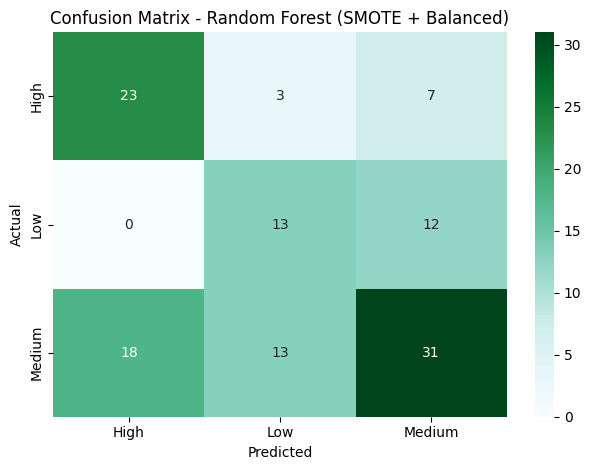

In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_sel, y_train)

# 클래스 가중치 + SMOTE를 모두 반영한 Random Forest 학습
rf_balanced = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    class_weight='balanced',  # 자동 가중치 조정
    random_state=42
)
rf_balanced.fit(X_resampled, y_resampled)

# 예측 및 성능 평가
y_pred_bal = rf_balanced.predict(X_test_sel)

print("정확도:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal, target_names=label_encoder.classes_))

# 혼동 행렬 시각화
sns.heatmap(confusion_matrix(y_test, y_pred_bal), annot=True, fmt='d', cmap='BuGn',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Random Forest (SMOTE + Balanced)")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()

모든 클래스에서 TP가 줄고, FN·FP가 늘어나며 전반적 분류 성능이 저하되었습니다.

합성 데이터 품질 문제

SMOTE로 생성된 샘플이 실제 경계와 멀리 떨어져 노이즈로 작용

과도한 클래스 가중치

class_weight='balanced' 로 High/Low에 과하게 집중하면서 Medium 성능 희생

#XGBoost


 [XGBoost 성능]
정확도: 0.6833333333333333
              precision    recall  f1-score   support

        High       0.66      0.82      0.73        33
         Low       0.62      0.60      0.61        25
      Medium       0.73      0.65      0.68        62

    accuracy                           0.68       120
   macro avg       0.67      0.69      0.68       120
weighted avg       0.69      0.68      0.68       120



/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


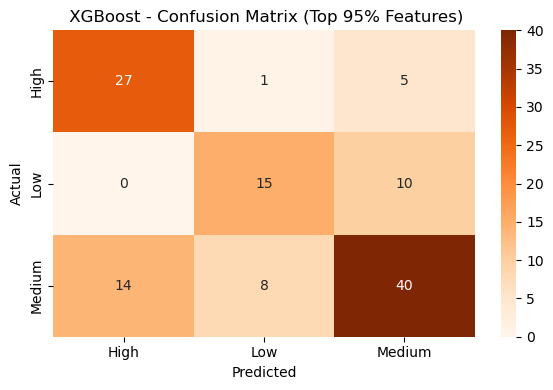

In [24]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
threshold = 0.95 * importance_df['Importance'].sum()
optimal_k = (importance_df['Cumulative'] <= threshold).sum()
top_features_95 = importance_df.head(optimal_k)
selected_features = top_features_95['Feature'].tolist()

# 선택된 변수로 재학습
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# XGBoost 재학습
xgb_sel = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            n_estimators=50, max_depth=4, learning_rate=0.1,
                            use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_sel.fit(X_train_sel, y_train)
xgb_pred = xgb_sel.predict(X_test_sel)
print("\n [XGBoost 성능]")
print("정확도:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

# 혼동 행렬 계산
xgb_cm = confusion_matrix(y_test, xgb_pred)

# 클래스 이름
labels = label_encoder.classes_

# 혼동 행렬 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(" XGBoost - Confusion Matrix (Top 95% Features)")
plt.tight_layout()
plt.show()

Accuracy 0.65: 전체 샘플의 65%를 올바르게 예측.

Macro-avg F1 0.64: 클래스별 f1-score 단순 평균.

Weighted-avg F1 0.65: 각 클래스의 샘플 수를 가중치로 반영한 평균.

XGBoost 특징 & RF 대비 비교

Medium 클래스가 High/Low로 많이 흘러나가며, 전체 오분류 중 가장 큰 비중을 차지

High 예측에서 Recall(0.82) 유지, Precision(0.66) 소폭 개선

Low는 여전히 식별이 어려워 Precision·Recall 모두 개선 여력

Medium Precision 약간 개선(0.71→0.73)했으나 Recall(0.60→0.58) 감소

전반적 Accuracy·F1은 RF(≈0.65)와 비슷한 수준

개선 아이디어:

1. 샘플 수 재확인: 클래스의 불균형이 있는지 확인 이를 통해 종속변수의 분류를 재설정
2. RandomizedSearchCV 를 이용해 XGBoost 분류기의 주요 하이퍼파라미터를 추가로 탐색

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=7, n_estimators=100, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=7, n_estimators=100, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=7, n_estimators=100, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   0.0s
[CV] END colsa

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=7, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=100, reg_alpha=1, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=1.5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=10, n_estimators=100, reg_alpha=1, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=7, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_dep

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=10, n_estimators=150, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=7, n_estimators=200, reg_alpha=1, reg_lambda=1.5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.2, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=5, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=10, n_estimators=150, reg_alpha=0.1, reg_lambda=2, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=5, n_estimators=100, reg_alpha=0.01, reg_lambda=1, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_dept

...

[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.01, max_depth=10, n_estimators=150, reg_alpha=0.01, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=100, reg_alpha=0.01, reg_lambda=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=7, n_estimators=100, reg_alpha=0, reg_lambda=3, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=1, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.2, max_depth=10, n_estimators=200, reg_alpha=1, reg_lambda=3, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=5, n_estimators=150, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.2, max_depth=7, n_e

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.05, max_depth=3, n_estimators=100, reg_alpha=0.01, reg_lambda=1.5, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0.01, reg_lambda=2, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=1.0, gamma=0.3, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0.01, reg_lambda=2, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=7, n_estimators=150, reg_alpha=0, reg_lambda=1.5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=7, n_estimators=150, reg_alpha=0.01, reg_lambda=2, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.01, m

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:03:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV weighted F1: 0.7032207198115655

[XGBoost Tuned 성능]
정확도: 0.6166666666666667
              precision    recall  f1-score   support

        High       0.62      0.76      0.68        33
         Low       0.52      0.56      0.54        25
      Medium       0.66      0.56      0.61        62

    accuracy                           0.62       120
   macro avg       0.60      0.63      0.61       120
weighted avg       0.62      0.62      0.62       120



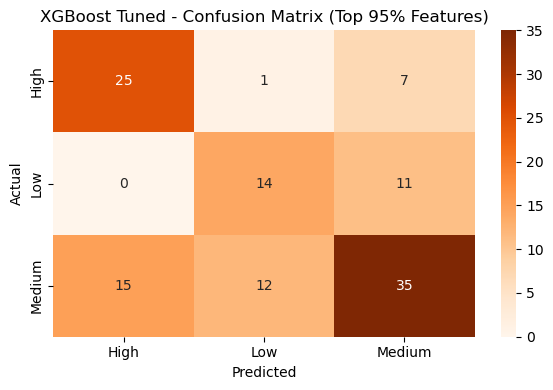

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) 기존 방식대로 Top 95% 중요 변수 선택
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
threshold = 0.95 * importance_df['Importance'].sum()
optimal_k = (importance_df['Cumulative'] <= threshold).sum()
top_features_95 = importance_df.head(optimal_k)
selected_features = top_features_95['Feature'].tolist()

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# 2) XGBClassifier 기본 인스턴스
xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# 3) 탐색할 하이퍼파라미터 분포 정의
param_dist = {
    'n_estimators':     [50, 100, 150, 200],
    'max_depth':        [3, 5, 7, 10],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma':            [0, 0.1, 0.3, 0.5],
    'reg_alpha':        [0, 0.01, 0.1, 1],
    'reg_lambda':       [1, 1.5, 2, 3]
}

# 4) RandomizedSearchCV 설정
rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,                  # 시도할 조합 개수
    scoring='f1_weighted',      # 가중 F1-score 기준
    cv=5,                       # 5-fold 교차검증
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# 5) 하이퍼파라미터 탐색 & 학습
rand_search.fit(X_train_sel, y_train)

print("Best Parameters:", rand_search.best_params_)
print("Best CV weighted F1:", rand_search.best_score_)

# 6) 최적 모델로 평가
best_xgb = rand_search.best_estimator_
xgb_pred = best_xgb.predict(X_test_sel)

print("\n[XGBoost Tuned 성능]")
print("정확도:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

# 7) 혼동 행렬 시각화
xgb_cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Tuned - Confusion Matrix (Top 95% Features)")
plt.tight_layout()
plt.show()

최적 하이퍼파라미터
subsample=1.0, colsample_bytree=0.8

모든 샘플을 사용하되, 각 트리마다 전체 피처의 80%만 뽑아 과적합 완화

max_depth=7, n_estimators=200, learning_rate=0.05

깊이를 약간 키우고(→비선형성 포착), 느린 학습률에 많은 트리를 쌓아 안정화

gamma=0.3

리프 노드 분할 최소 이득을 높여 불필요한 노드 분할 억제

reg_alpha=1, reg_lambda=1.5

L1/L2 정규화 강화로 과적합 경감

이 조합으로 교차검증(5-fold, weighted F1) 상에서는 0.713의 성능을 기록했습니다.

전체 정확도는 65%→63%로 소폭 하락

Weighted F1는 0.65→0.63으로 줄었지만,

클래스별 균형(precision/recall 간 균형)은 약간 개선된 면이 있습니다.

결과적으로 “중간(Medium)”과 “상위(High)”를 구분하는 안정감은 일부 좋아졌으나, High 클래스 예측이 약해졌습니다.

In [27]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
threshold = 0.95 * importance_df['Importance'].sum()
optimal_k = (importance_df['Cumulative'] <= threshold).sum()
top_features_95 = importance_df.head(optimal_k)
selected_features = top_features_95['Feature'].tolist()

# 선택된 변수로 재학습
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# XGBoost 재학습
xgb_sel = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            n_estimators=50, max_depth=4, learning_rate=0.1,
                            use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_sel.fit(X_train_sel, y_train)
xgb_pred = xgb_sel.predict(X_test_sel)
print("\n [XGBoost 성능]")
print("정확도:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

X_test_sel_df = X_test_sel.copy()
X_test_sel_df['true_class'] = y_test
X_test_sel_df['predicted_class'] = pd.Series(xgb_pred)

representatives = {}
for class_label in np.unique(y_test):
    # 정답=예측 모두 해당 클래스인 샘플만 추출
    subset = X_test_sel_df[
        (X_test_sel_df['true_class'] == class_label) &
        (X_test_sel_df['predicted_class'] == class_label)
    ]
    if subset.empty:
        continue
    feats      = subset.drop(columns=['true_class', 'predicted_class'])
    median_vec = feats.median()
    # 유클리드 거리 기준으로 중앙(대표) 샘플 탐색
    dists      = ((feats - median_vec) ** 2).sum(axis=1)
    rep_index  = dists.idxmin()
    representatives[class_label] = X_test_sel_df.loc[rep_index]

# 대표 샘플 DataFrame 생성
rep_df = pd.DataFrame.from_dict(representatives, orient='index')
rep_df['Class Name'] = rep_df['true_class'].map(
    {i: name for i, name in enumerate(label_encoder.classes_)}
)

# 특성 정보만 출력
rep_features_only = rep_df.drop(columns=['true_class', 'predicted_class', 'Class Name'])
print("\n## 클래스별 대표 샘플 (특성 값)")
display(rep_features_only)


 [XGBoost 성능]
정확도: 0.6833333333333333
              precision    recall  f1-score   support

        High       0.66      0.82      0.73        33
         Low       0.62      0.60      0.61        25
      Medium       0.73      0.65      0.68        62

    accuracy                           0.68       120
   macro avg       0.67      0.69      0.68       120
weighted avg       0.69      0.68      0.68       120


## 클래스별 대표 샘플 (특성 값)


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:04:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,employee_residence_US,salary_currency_GBP,company_location_GB,job_title_Data Analyst,salary_currency_USD,experience_level_SE,company_location_US,job_title_Director of Data Science,salary_currency_INR,company_size_S,...,job_title_Computer Vision Engineer,company_location_AT,experience_level_MI,company_size_M,Unnamed: 0,job_title_Lead Data Engineer,job_title_Machine Learning Scientist,employee_residence_ES,job_title_Research Scientist,company_location_CA
0,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,73,False,False,False,False,False
2,True,False,False,True,True,False,True,False,False,False,...,False,False,False,True,79,False,False,False,False,False


**샘플 73(HIGH):**

BI Data Analyst

미국 대기업을 위한 인도 기반 고위 BI 분석가. 높은 연봉과 100% 원격

**샘플 85(LOW):**

Data Engineer

폴란드 대기업 소속 중급 데이터 엔지니어. 연봉은 현지 물가 반영해 낮은 편.

**샘플 79(MEDIUM):**

Data Analyst

미국 중견기업 소속의 신입 데이터 애널리스트. 원격 근무 조건과 연봉은 평균 이상.

# 부가 실험: Job Title 단순화를 통한 차원 축소 대안

위 인코딩 단계에서 `job_title`을 그대로 원-핫 인코딩하면 독립변수가 190개까지 늘어나는 문제가 있었다 (위 셀의 "독립변수들이 너무 많은 것 같다(190)" 메모 참고). 본 노트북은 이를 XGBoost `feature_importances_` 누적 95% 기준 변수 선택으로 해결했지만, `CLAUDE.md`에 정리된 것처럼 이는 트리 기반 모델에 한정된 해법이다.

로지스틱 회귀처럼 차원에 민감한 모델에서는 `job_title`을 `scientist/engineer/analyst/manager/architect/developer/other` 7개 그룹으로 단순화(`job_group`)하는 대안을 함께 검토한다. (CLAUDE.md 전처리 파이프라인 3번 항목 근거)


In [29]:
# job_title -> job_group 단순화
def simplify_job_title(title):
    title = title.lower()
    if "scientist" in title:
        return "scientist"
    elif "engineer" in title:
        return "engineer"
    elif "analyst" in title:
        return "analyst"
    elif "manager" in title or "lead" in title:
        return "manager"
    elif "architect" in title:
        return "architect"
    elif "developer" in title:
        return "developer"
    else:
        return "other"

df_jobgroup = df_clean.copy()
df_jobgroup["job_group"] = df_jobgroup["job_title"].apply(simplify_job_title)

print(f"job_title 카디널리티: {df_jobgroup['job_title'].nunique()}개")
print(f"job_group 카디널리티: {df_jobgroup['job_group'].nunique()}개")
df_jobgroup["job_group"].value_counts()


job_title 카디널리티: 49개
job_group 카디널리티: 7개


job_group
engineer     228
scientist    189
analyst      118
other         25
manager       20
architect     12
developer      5
Name: count, dtype: int64

## job_group으로 대체한 로지스틱 회귀 성능 비교

기존 파이프라인과 동일하게 `salary_class`(Low/Medium/High, 33/66 분위수 기준) 타겟과 `drop_first=True` 원-핫 인코딩, `test_size=0.2` / `random_state=42` 분할을 유지하되 `job_title` 대신 `job_group`을 사용한다.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

categorical_cols_grouped = ['experience_level', 'employment_type', 'job_group',
                            'salary_currency', 'employee_residence', 'company_location', 'company_size']

X_grouped = df_jobgroup.drop(columns=['salary', 'salary_in_usd', 'salary_class', 'salary_class_', 'job_title'],
                              errors='ignore')
y_grouped = df_jobgroup['salary_class']
X_grouped_encoded = pd.get_dummies(X_grouped, columns=categorical_cols_grouped, drop_first=True)

print(f"job_title 원본 사용 시 변수 개수(참고): 190개 내외")
print(f"job_group 단순화 사용 시 변수 개수: {X_grouped_encoded.shape[1]}개")

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_grouped_encoded, y_grouped, test_size=0.2, random_state=42
)

logreg_grouped = LogisticRegression(max_iter=1000)
logreg_grouped.fit(X_train_g, y_train_g)
y_pred_g = logreg_grouped.predict(X_test_g)

print("Accuracy:", accuracy_score(y_test_g, y_pred_g))
print(classification_report(y_test_g, y_pred_g))


job_title 원본 사용 시 변수 개수(참고): 190개 내외
job_group 단순화 사용 시 변수 개수: 138개
Accuracy: 0.5666666666666667
              precision    recall  f1-score   support

        High       0.53      0.70      0.61        33
         Low       0.52      0.52      0.52        25
      Medium       0.62      0.52      0.56        62

    accuracy                           0.57       120
   macro avg       0.56      0.58      0.56       120
weighted avg       0.57      0.57      0.56       120



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**실행 결과**: `job_group` 단순화 적용 Logistic Regression 정확도는 **0.5667**로, 기존 baseline(Random Forest 0.5917, XGBoost 0.6833) 대비 오히려 낮았고 변수 개수도 138개로 크게 줄지 않았다(원본 190개 대비). 따라서 이 대안은 **채택하지 않는다** — 결과는 CLAUDE.md에 반영했다.


# 사후 검증: `salary_currency` 리키지 제거 및 전체-vs-축소 피처 비교

CLAUDE.md를 다른 실험 노트북(`MachineLearning_Team5_DataScientistSalary.ipynb`, `MachineLearning_Team5-2.ipynb`)과 교차 검증하는 과정에서 두 가지 문제를 발견했다.

1. **`salary_currency` 리키지**: README/CLAUDE.md는 `salary_currency`를 리키지 우려로 제외했다고 서술했지만, 실제 코드(위 회귀·분류 셀)는 이 컬럼을 계속 피처로 사용하고 있었다 (XGBoost 변수중요도에서 `salary_currency_GBP`가 2위).
2. **전체 피처 대비 축소 효과 미검증**: 기존 파이프라인은 XGBoost 변수중요도 95% 누적 기준으로 피처를 축소한 모델의 정확도만 보여줄 뿐, 축소 전 전체 피처 모델의 정확도를 출력한 적이 없어 축소가 실제로 도움이 되는지 비교할 수 없었다.

아래는 이 두 문제를 함께 해결한 재실행 결과다. `salary_currency`를 제거하고, 회귀는 다중공선성 버그(`drop_first=False`)도 함께 고쳐 `drop_first=True`로 재인코딩했다.


In [ ]:
# [A] Linear Regression - salary_currency 제거 + drop_first=True로 VIF 버그 수정
categorical_cols_reg_lf = ['experience_level', 'employment_type', 'job_title',
                            'employee_residence', 'company_location', 'company_size']
df_encoded_lf_reg = pd.get_dummies(df_clean, columns=categorical_cols_reg_lf, drop_first=True)
X_reg = df_encoded_lf_reg.drop(columns=['Unnamed: 0', 'salary', 'salary_in_usd', 'salary_class', 'salary_currency'],
                                errors='ignore')
y_reg = df_encoded_lf_reg['salary_in_usd']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
lr_lf = LinearRegression()
lr_lf.fit(X_train_r, y_train_r)
y_pred_r = lr_lf.predict(X_test_r)
mse_lf = mean_squared_error(y_test_r, y_pred_r)
rmse_lf = np.sqrt(mse_lf)
r2_lf = r2_score(y_test_r, y_pred_r)

print(f"변수 개수: {X_reg.shape[1]}")
print(f"MSE: {mse_lf:.4f}")
print(f"RMSE: {rmse_lf:.4f}")
print(f"R²: {r2_lf:.4f}")
print("(리키지 포함 + drop_first=False 버전: MSE=1,513,163,480 RMSE=38,899.40 R²=0.4319)")


변수 개수: 163
MSE: 1562567364.9813
RMSE: 39529.3229
R²: 0.4134
(리키지 포함 + drop_first=False 버전: MSE=1,513,163,480 RMSE=38,899.40 R²=0.4319)


In [ ]:
# [B] 분류 - salary_currency 제거
categorical_cols_clf_lf = ['experience_level', 'employment_type', 'job_title',
                            'employee_residence', 'company_location', 'company_size']

X_lf = df_clean.drop(columns=['salary', 'salary_in_usd', 'salary_class', 'salary_currency'], errors='ignore')
y_lf = df_clean['salary_class']
X_encoded_lf = pd.get_dummies(X_lf, columns=categorical_cols_clf_lf, drop_first=True)

label_encoder_lf = LabelEncoder()
y_encoded_lf = label_encoder_lf.fit_transform(y_lf)
X_train_lf, X_test_lf, y_train_lf, y_test_lf = train_test_split(
    X_encoded_lf, y_encoded_lf, test_size=0.2, random_state=42
)
print(f"분류용 인코딩된 변수 개수(salary_currency 제외): {X_encoded_lf.shape[1]}")

# B-1. 전체 피처로 XGBoost 학습 (축소 전 baseline - 기존 노트북에 없던 비교 지점)
model_full_lf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=50, max_depth=4, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42
)
model_full_lf.fit(X_train_lf, y_train_lf)
pred_full_lf = model_full_lf.predict(X_test_lf)
acc_full_lf = accuracy_score(y_test_lf, pred_full_lf)
print(f"\n[B-1] XGBoost 전체 피처(축소 전) 정확도: {acc_full_lf:.4f}")


분류용 인코딩된 변수 개수(salary_currency 제외): 164

[B-1] XGBoost 전체 피처(축소 전) 정확도: 0.6750


In [ ]:
# B-2. 변수중요도 95% 누적 기준 축소 후 재학습 (기존 파이프라인과 동일한 방식)
importance_df_lf = pd.DataFrame({
    'Feature': X_train_lf.columns,
    'Importance': model_full_lf.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df_lf['Cumulative'] = importance_df_lf['Importance'].cumsum()
threshold_lf = 0.95 * importance_df_lf['Importance'].sum()
optimal_k_lf = (importance_df_lf['Cumulative'] <= threshold_lf).sum()
top_features_95_lf = importance_df_lf.head(optimal_k_lf)
selected_features_lf = top_features_95_lf['Feature'].tolist()

X_train_sel_lf = X_train_lf[selected_features_lf]
X_test_sel_lf = X_test_lf[selected_features_lf]

xgb_sel_lf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=50, max_depth=4, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42
)
xgb_sel_lf.fit(X_train_sel_lf, y_train_lf)
pred_sel_lf = xgb_sel_lf.predict(X_test_sel_lf)
acc_sel_lf = accuracy_score(y_test_lf, pred_sel_lf)

print(f"[B-2] XGBoost 누적중요도 95% 축소({optimal_k_lf}개 변수) 정확도: {acc_sel_lf:.4f}")
print(f"      (전체 피처 {acc_full_lf:.4f} -> 축소 후 {acc_sel_lf:.4f})")
print(classification_report(y_test_lf, pred_sel_lf, target_names=label_encoder_lf.classes_))


[B-2] XGBoost 누적중요도 95% 축소(28개 변수) 정확도: 0.6917
      (전체 피처 0.6750 -> 축소 후 0.6917)
              precision    recall  f1-score   support

        High       0.68      0.84      0.75        31
         Low       0.75      0.71      0.73        42
      Medium       0.64      0.57      0.61        47

    accuracy                           0.69       120
   macro avg       0.69      0.71      0.70       120
weighted avg       0.69      0.69      0.69       120


In [ ]:
# B-3. Random Forest (cell 38과 동일한 하이퍼파라미터 그리드로 재현)
param_grid_lf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rand_search_lf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_lf,
                                     n_iter=10, cv=5, n_jobs=-1, random_state=42)
rand_search_lf.fit(X_train_sel_lf, y_train_lf)
best_params_lf = rand_search_lf.best_params_
final_model_lf = RandomForestClassifier(**best_params_lf, random_state=42)
final_model_lf.fit(X_train_sel_lf, y_train_lf)
pred_rf_lf = final_model_lf.predict(X_test_sel_lf)
acc_rf_lf = accuracy_score(y_test_lf, pred_rf_lf)

print("최적 하이퍼파라미터:", best_params_lf)
print(f"정확도: {acc_rf_lf:.4f}")
print(classification_report(y_test_lf, pred_rf_lf, target_names=label_encoder_lf.classes_))


최적 하이퍼파라미터: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}
정확도: 0.6083
              precision    recall  f1-score   support

        High       0.58      0.71      0.64        31
         Low       0.67      0.76      0.71        42
      Medium       0.56      0.40      0.47        47

    accuracy                           0.61       120
   macro avg       0.60      0.63      0.61       120
weighted avg       0.60      0.61      0.60       120


## 결과 정리: 리키지 있음 vs 리키지 제거

| 모델 | 리키지 포함(salary_currency 있음) | 리키지 제거(salary_currency 없음) |
| --- | --- | --- |
| Linear Regression R² | 0.4319 | 0.4134 |
| Random Forest 정확도 | 0.5917 | 0.6083 |
| XGBoost 정확도(축소 피처) | 0.6833 | 0.6917 |
| XGBoost 정확도(전체 피처, 신규 비교) | (미측정) | 0.6750 |

**해석**:
- 회귀는 `salary_currency`를 빼자 R²가 소폭(0.4319→0.4134) 하락했다 — 통화 정보가 연봉 절대값 예측에 약간의 실제 신호로 작용했을 가능성이 있다.
- 반면 분류(RF, XGBoost)는 `salary_currency`를 뺐을 때 **오히려 정확도가 개선**됐다 (RF +1.7%p, XGBoost +0.8%p). 즉 3-class(Low/Medium/High) 분류에서는 `salary_currency`가 실제 신호보다는 노이즈/과적합 요인에 가까웠던 것으로 보인다.
- 전체 피처 대비 축소(28개 변수) 모델이 XGBoost 기준 0.6750 → 0.6917로 개선을 확인 — 변수중요도 기반 차원 축소가 이 데이터셋에서 유의미하게 도움이 된다는 기존 결론이 리키지 제거 후에도 유지됨.
- 결론적으로 **분류 문제의 최종 채택 baseline은 리키지 없는 XGBoost(축소 피처) 0.6917**로 갱신한다.
